# MNIST 데이터셋 확인

MNIST는 손으로 쓴 숫자 이미지 데이터셋으로, 이미지 인식과 딥러닝 학습에서 널리 사용됩니다.

---

## 📌 실습 과제: MNIST 데이터 로드 및 이미지 표시

이 섹션의 코드는 이후 실습 과제에서 `import` 형태로 재사용됩니다.

In [2]:
# coding: utf-8
# ============================================
# 실습 과제: MNIST 데이터 로드 및 이미지 표시
# ============================================

# 필요한 라이브러리 Import
import sys, os

# 현재 작업 디렉토리 출력
print(f"현재 작업 디렉토리: {os.getcwd()}")

# 추가 Library를 위한 PATH 추가
# 현재 디렉토리(ch02)의 바로 상위 디렉토리에 dataset 모듈이 있습니다
# os.getcwd()가 ch02를 반환하므로, dirname을 한 번만 호출하면 됩니다
current_dir = os.getcwd()
dataset_dir = os.path.dirname(current_dir)  # DL3_20241006 디렉토리
print(f"dataset 디렉토리: {dataset_dir}")

# dataset 모듈이 있는 디렉토리를 Python path에 추가
sys.path.insert(0, dataset_dir)

# 추가 Library import
import numpy as np
from dataset.mnist import load_mnist
from PIL import Image
import matplotlib.pyplot as plt

현재 작업 디렉토리: c:\Users\coco9\Desktop\project\DL-Excersize\notebooks\DL3_20241006\ch02
dataset 디렉토리: c:\Users\coco9\Desktop\project\DL-Excersize\notebooks\DL3_20241006


In [3]:
# ============================================
# 실습 과제: MNIST 이미지 표시 함수
# ============================================

# Image drawing 부분
# MNIST 이미지를 표시하는 함수 정의
def img_show(img):
    """
    MNIST 이미지를 표시하는 함수
    
    Parameters
    ----------
    img : numpy array
        2차원 이미지 배열 (28x28)
    """
    # matplotlib를 사용하여 흑백 이미지로 표시
    plt.imshow(img, cmap='gray')
    plt.axis('off')  # 축 숨기기
    plt.show()
    
    # PIL을 사용하여 이미지 표시 (선택 사항)
    # pil_img = Image.fromarray(np.uint8(img))
    # pil_img.show()

레이블: 5  # 5
변경 전 이미지 형태: (784,)
변경 후 이미지 형태: (28, 28)


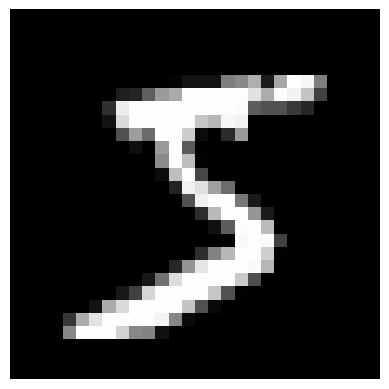

In [4]:
# ============================================
# 실습 과제: MNIST 데이터 로딩
# ============================================

# MNIST 데이터 로딩 (인터넷에서 다운로드)
# flatten=True: 이미지를 1차원 배열로 펼침 (784차원)
# normalize=False: 픽셀 값을 정규화하지 않음 (0~255 유지)
(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=False)

# 첫 번째 훈련 이미지와 레이블 가져오기
img = x_train[0]
label = t_train[0]
print(f"레이블: {label}  # 5")

# 1차원 이미지를 2차원 이미지로 변경
# 784개의 픽셀을 28x28 형태로 변환
print(f"변경 전 이미지 형태: {img.shape}")  # (784,)
img = img.reshape(28, 28)  # 형태를 원래 이미지의 크기로 변환
print(f"변경 후 이미지 형태: {img.shape}")  # (28, 28)

# MNIST 이미지 표시
img_show(img)

---

## 📖 설명: MNIST 데이터 이해하기

이 섹션에서는 MNIST 데이터셋의 특징과 데이터를 더 자세히 분석합니다.

### MNIST 데이터셋 개요

| 항목 | 내용 |
|------|------|
| 훈련 데이터 | 60,000개 이미지 (28×28 픽셀, 흑백) |
| 테스트 데이터 | 10,000개 이미지 (28×28 픽셀, 흑백) |
| 레이블 | 0~9 숫자 (10 클래스) |
| 이미지 형태 | 1채널 (회색조), 픽셀 값 0~255 |

In [ ]:
# 데이터 형태 확인
print(f"훈련 이미지 형태: {x_train.shape}")  # (60000, 784)
print(f"훈련 레이블 형태: {t_train.shape}")  # (60000,)
print(f"테스트 이미지 형태: {x_test.shape}")   # (10000, 784)
print(f"테스트 레이블 형태: {t_test.shape}")   # (10000,)

# 레이블 범위 확인
print(f"\n훈련 레이블 범위: {t_train.min()} ~ {t_train.max()}")
print(f"테스트 레이블 범위: {t_test.min()} ~ {t_test.max()}")

### 여러 MNIST 이미지 확인

여러 개의 MNIST 이미지를 한 번에 확인하고 데이터의 특성을 분석해봅니다.

In [ ]:
# 여러 MNIST 이미지 한 번에 표시
def show_multiple_images(images, labels, num_show=10):
    """
    여러 MNIST 이미지를 한 번에 표시
    
    Parameters
    ----------
    images : numpy array
        이미지 배열 (N, 784) 또는 (N, 28, 28)
    labels : numpy array
        레이블 배열 (N,)
    num_show : 표시할 이미지 개수
    """
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    
    for i, ax in enumerate(axes.flat):
        if i >= num_show:
            break
            
        # 1차원 이미지를 2차원으로 변환
        img = images[i].reshape(28, 28)
        ax.imshow(img, cmap='gray')
        ax.set_title(f"레이블: {labels[i]}")
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# 훈련 데이터에서 10개 이미지 표시
show_multiple_images(x_train, t_train, 10)

In [ ]:
# 각 클래스(0~9)별 이미지 개수 확인
print("각 클래스별 훈련 데이터 개수:")
for i in range(10):
    count = np.sum(t_train == i)
    print(f"  클래스 {i}: {count}개")

# 각 클래스별 대표 이미지 표시
fig, axes = plt.subplots(2, 5, figsize=(15, 5))

for i, ax in enumerate(axes.flat):
    # 클래스 i에 해당하는 첫 번째 이미지 찾기
    idx = np.where(t_train == i)[0][0]
    img = x_train[idx].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"클래스 {i} ({np.sum(t_train == i)}개)")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# 이미지 픽셀 값 분석
img_sample = x_train[0].reshape(28, 28)

print(f"픽셀 값 통계:")
print(f"  최소값: {img_sample.min()}")
print(f"  최대값: {img_sample.max()}")
print(f"  평균값: {img_sample.mean():.2f}")
print(f"  표준편차: {img_sample.std():.2f}")

# 픽셀 값 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 이미지 표시
axes[0].imshow(img_sample, cmap='gray')
axes[0].set_title(f"이미지 (레이블: {t_train[0]})")
axes[0].axis('off')

# 픽셀 값 히스토그램
axes[1].hist(x_train[0], bins=256, range=(0, 255), color='gray', alpha=0.7)
axes[1].set_title('픽셀 값 분포')
axes[1].set_xlabel('픽셀 값')
axes[1].set_ylabel('빈도')

plt.tight_layout()
plt.show()

---

## 보충 자료: MNIST 데이터 이해하기

### 데이터 형태 변환

MNIST 이미지는 다음과 같은 형태로 변환되어 사용됩니다:

| 형태 | 설명 | 사용 목적 |
|------|------|----------|
| (28, 28) | 2차원 이미지 | 시각화 |
| (784,) | 1차원 벡터 | 완전연결층 입력 |
| (1, 28, 28) | 채널+높이+너비 | 합성곱층 입력 |
| (N, 28, 28) | 배치+높이+너비 | 배치 처리 |
| (N, 1, 28, 28) | 배치+채널+높이+너비 | 합성곱 신경망 배치 |

### load_mnist() 파라미터

| 파라미터 | 설명 | 기본값 |
|----------|------|--------|
| `normalize` | 픽셀 값을 0.0~1.0으로 정규화 | `True` |
| `flatten` | 이미지를 1차원 배열로 펼침 | `True` |
| `one_hot_label` | 레이블을 원-핫 인코딩으로 변환 | `False` |

### MNIST 데이터셋 특징

- **간단한 이미지 인식 학습**에 적합한 데이터셋
- 현대적인 모델로 테스트 정확도 99% 이상 달성 가능
- 합성곱 신경망(CNN) 학습의 "Hello World"로 불림
- 첫 번째 숫자(0)부터 아홉 번째 숫자(9)까지 10개 클래스로 구성